In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.datasets import make_moons, make_circles 

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score

from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

from scipy.stats import spearmanr

# Code for Metric Score Calculations

In [2]:
def full_cw_sil_score(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    #pairwise distance matrix
    D = cdist(X, X)

    # computation of centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # to avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # to exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist * inter_weights) / np.sum(inter_weights)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

In [3]:
def cw_sil_score(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    # pairwise distance matrix
    D = cdist(X, X)

    # centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            #inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist) / len(inter_dist)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

In [4]:
def dunn_index(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    # Compute pairwise distances
    D = cdist(X, X)

    # Intra-cluster diameter (max distance inside cluster)
    intra_dists = []
    for l in unique_labels:
        cluster_points = np.where(labels == l)[0]
        if len(cluster_points) < 2:
            continue
        cluster_D = D[np.ix_(cluster_points, cluster_points)]
        intra_dists.append(np.max(cluster_D))

    if len(intra_dists) == 0:
        return 0

    max_intra = np.max(intra_dists)

    # Inter-cluster distance (min distance between clusters)
    inter_dists = []
    for i, li in enumerate(unique_labels):
        for lj in unique_labels[i+1:]:
            cluster_i = np.where(labels == li)[0]
            cluster_j = np.where(labels == lj)[0]
            inter_cluster_D = D[np.ix_(cluster_i, cluster_j)]
            inter_dists.append(np.min(inter_cluster_D))

    min_inter = np.min(inter_dists)

    return min_inter / max_intra

In [5]:
# from https://github.com/nobertomaciel/sklearn/blob/main/xie_beni.py

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import pairwise_distances
from sklearn.utils.validation import check_X_y
from sklearn.utils import _safe_indexing


# Author: Noberto Maciel <nobertomaciel@hotmail.com>
# License: BSD 3 clause

def xie_beni_index(X, labels):
    """Compute the Xie Beni Index.

    Xie and Beni introduced Xie-Beni (XB) index method in 1991. 
    XB index is focus on separation and compactness. 
    Separation is a measure of the distance between one cluster and 
    another cluster and compactness is a measure of proximity between data 
    points in a cluster (Lathief 2020).

    The minimum score is zero, with lower values indicating better clustering.

    Read more in the :ref:`User Guide <xie-beni_index>`.

    .. versionadded:: 0.10

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        A list of ``n_features``-dimensional data points. Each row corresponds
        to a single data point.

    labels : array-like of shape (n_samples,)
        Predicted labels for each sample.

    Returns
    -------
    score: float
        The resulting Xie Beni Index.

    References
    ----------
    .. [1] XIE, Xuanli Lisa ; BENI, Gerardo. 
        A validity measure for fuzzy clustering. 
        IEEE Transactions on Pattern Analysis & Machine Intelligence, 
        v. 13, n. 08, p. 841-847, 1991.
       [2] LATHIEF, Muttabik Fathul; SOESANTI, Indah; PERMANASARI, Adhistya Erna. 
        Combination of Fuzzy C-Means, Xie-Beni Index, and Backpropagation Neural Network for Better Forecasting Result. 
        Science and Technology Publications: Setubal, Portugal, 
        p. 72-77, 2020.
    """
    def check_number_of_labels(n_labels, n_samples):
        """Check that number of labels are valid.

        Parameters
        ----------
        n_labels : int
            Number of labels.

        n_samples : int
            Number of samples.
        """
        if not 1 < n_labels < n_samples:
            raise ValueError(
                "Number of labels is %d. Valid values are 2 to n_samples - 1 (inclusive)"
                % n_labels
            )
    X, labels = check_X_y(X, labels)
    le = LabelEncoder()
    labels = le.fit_transform(labels)
    n_samples, _ = X.shape
    n_labels = len(le.classes_)
    check_number_of_labels(n_labels, n_samples)

    intra_dists = np.zeros(n_labels) # same cluster dist
    centroids = np.zeros((n_labels, len(X[0])), dtype=float)
    for k in range(n_labels):
        cluster_k = _safe_indexing(X, labels == k)
        centroid = cluster_k.mean(axis=0)
        centroids[k] = centroid
        intra_dists[k] = np.sum((pairwise_distances(cluster_k, [centroid])**2))

    centroid_distances = pairwise_distances(centroids)

    if np.allclose(intra_dists, 0) or np.allclose(centroid_distances, 0):
        return 0.0

    centroid_distances[centroid_distances == 0] = np.inf

    scores = (np.sum(intra_dists))/(n_labels*(np.min((centroid_distances**2))))
    return scores

In [6]:
# from https://github.com/Simon-Bertrand/Clusters-Features/blob/main/ClustersFeatures/src/_score_index.py
# chatgpt's function version from the class version in this github repo

def pbm_index(X, labels):
    X, labels = check_X_y(X, labels)
    labels = LabelEncoder().fit_transform(labels)

    n_clusters = len(np.unique(labels))
    if n_clusters < 2:
        raise ValueError("PBM index requires at least 2 clusters")

    # Global barycenter
    global_center = X.mean(axis=0)

    # ET: total scatter
    ET = np.linalg.norm(X - global_center, axis=1).sum()

    # Cluster centroids and EW
    centroids = []
    EW = 0.0
    for k in range(n_clusters):
        cluster_k = X[labels == k]
        centroid = cluster_k.mean(axis=0)
        centroids.append(centroid)
        EW += np.linalg.norm(cluster_k - centroid, axis=1).sum()

    centroids = np.array(centroids)

    # Max inter-centroid distance
    Dmax = pairwise_distances(centroids).max()

    pbm = ((ET * Dmax) / (EW * n_clusters)) ** 2
    return pbm

In [7]:
def evaluate_all(X, labels):
    return {
        "Standard-Silhouette": silhouette_score(X, labels),
        "Full-CW-Silhouette": full_cw_sil_score(X, labels),
        "CW-Silhouette": cw_sil_score(X, labels),
        "DBI": davies_bouldin_score(X, labels),
        "CHI": calinski_harabasz_score(X, labels),
        "Dunn": dunn_index(X, labels),
        "XBI": xie_beni_index(X, labels),
        "PBM": pbm_index(X, labels),
    }

# Concentric Circle Clusters

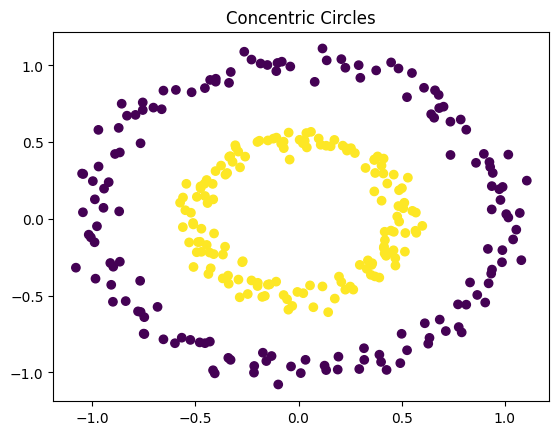

In [8]:
X_circles, y_circles = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=51)

plt.figure()
plt.scatter(X_circles[:,0], X_circles[:,1], c=y_circles)
plt.title("Concentric Circles")
plt.show()


In [9]:
model = DBSCAN(eps=0.2, min_samples=5)
pred_circles_db = model.fit_predict(X_circles)

scores_circles_db = evaluate_all(X_circles, pred_circles_db)

ari_circles_db = adjusted_rand_score(labels_true=y_circles, labels_pred=pred_circles_db)
nmi_circles_db = normalized_mutual_info_score(labels_true=y_circles, labels_pred=pred_circles_db)


In [10]:
model = KMeans(n_clusters=2, random_state=51, n_init=10)
pred_circles_km = model.fit_predict(X_circles)

scores_circles_km = evaluate_all(X_circles, pred_circles_km)

ari_circles_km = adjusted_rand_score(labels_true=y_circles, labels_pred=pred_circles_km)
nmi_circles_km = normalized_mutual_info_score(labels_true=y_circles, labels_pred=pred_circles_km)


In [11]:
df_circles_compare = pd.DataFrame({
    "Metric": list(scores_circles_km.keys()) + ["ARI", "NMI"],
    "KMeans": list(scores_circles_km.values()) + [ari_circles_km, nmi_circles_km],
    "DBSCAN": list(scores_circles_db.values()) + [ari_circles_db, nmi_circles_db],
})

display(df_circles_compare)

,Metric,KMeans,DBSCAN
0,Standard-Silhouette,0.352020,1.089716e-01
1,Full-CW-Silhouette,0.423042,1.097221e-01
2,CW-Silhouette,0.457620,1.111519e-01
3,DBI,1.177765,3.574708e+02
4,CHI,172.833391,2.094235e-03
5,Dunn,0.017265,1.124911e-01
6,XBI,64.646150,5.336077e+06
7,PBM,0.410352,4.454276e-06
8,ARI,-0.003177,1.000000e+00
9,NMI,0.000128,1.000000e+00


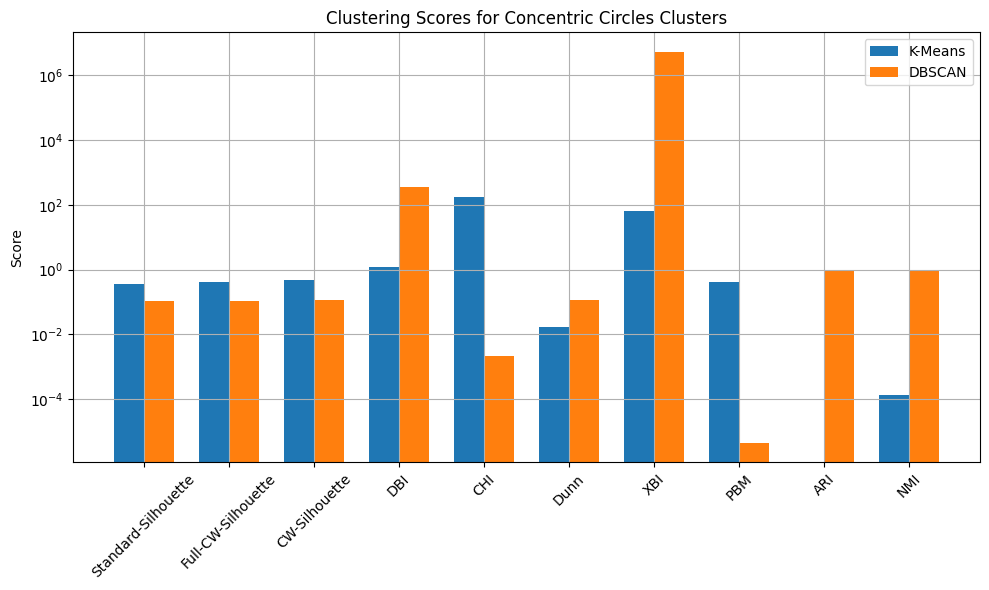

In [12]:
x = np.arange(len(df_circles_compare))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, df_circles_compare["KMeans"], width, label="K-Means")
plt.bar(x + width/2, df_circles_compare["DBSCAN"], width, label="DBSCAN")

plt.xticks(x, df_circles_compare["Metric"], rotation=45)
plt.ylabel("Score")
plt.yscale("log")
plt.title("Clustering Scores for Concentric Circles Clusters")
plt.legend()
plt.tight_layout()
plt.grid()

plt.show()

# Moon Clusters

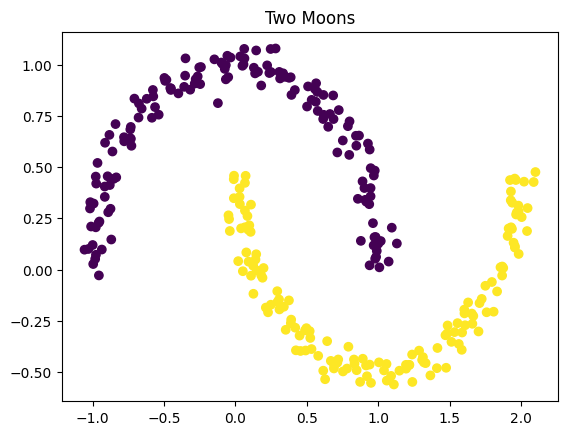

In [13]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=51)

plt.figure()
plt.scatter(X_moons[:,0], X_moons[:,1], c=y_moons)
plt.title("Two Moons")
plt.show()

In [14]:
model = DBSCAN(eps=0.2, min_samples=5)
pred_moons_db = model.fit_predict(X_moons)

scores_moons_db = evaluate_all(X_moons, pred_moons_db)

ari_moons_db = adjusted_rand_score(labels_true=y_moons, labels_pred=pred_moons_db)
nmi_moons_db = normalized_mutual_info_score(labels_true=y_moons, labels_pred=pred_moons_db)


In [15]:
model = KMeans(n_clusters=2, random_state=51, n_init=10)
pred_moons_km = model.fit_predict(X_moons)

scores_moons_km = evaluate_all(X_moons, pred_moons_km)

ari_moons_km = adjusted_rand_score(labels_true=y_moons, labels_pred=pred_moons_km)
nmi_moons_km = normalized_mutual_info_score(labels_true=y_moons, labels_pred=pred_moons_km)


In [16]:
df_moons_compare = pd.DataFrame({
    "Metric": list(scores_moons_km.keys()) + ["ARI", "NMI"],
    "KMeans": list(scores_moons_km.values()) + [ari_moons_km, nmi_moons_km],
    "DBSCAN": list(scores_moons_db.values()) + [ari_moons_db, nmi_moons_db],
})

display(df_moons_compare)

,Metric,KMeans,DBSCAN
0,Standard-Silhouette,0.492394,0.326716
1,Full-CW-Silhouette,0.514204,0.367611
2,CW-Silhouette,0.518459,0.365142
3,DBI,0.775874,1.167608
4,CHI,446.709055,193.053282
5,Dunn,0.020158,0.169964
6,XBI,25.011835,57.885574
7,PBM,1.422646,0.628359
8,ARI,0.254217,1.000000
9,NMI,0.194105,1.000000


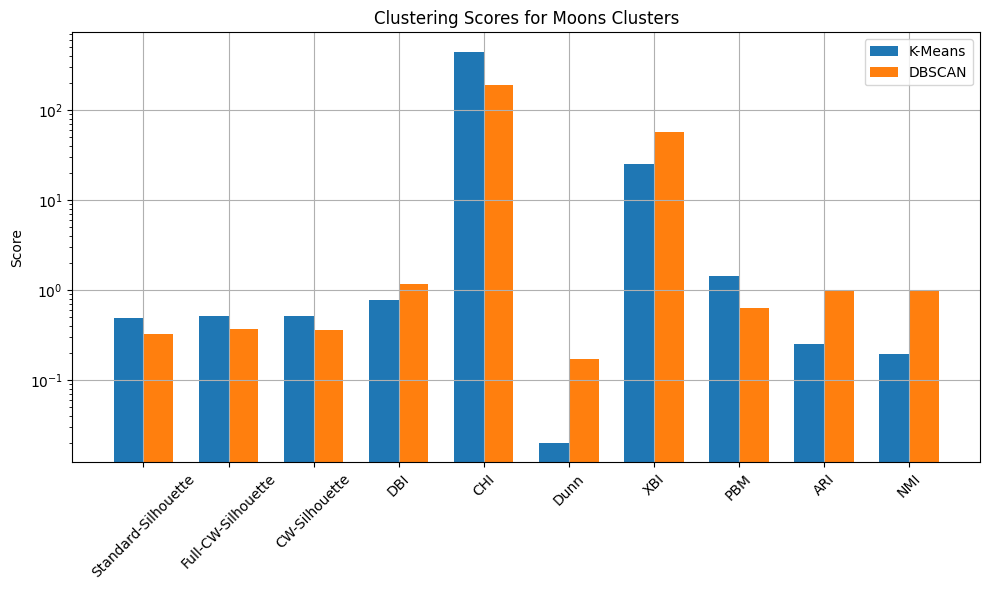

In [17]:
x = np.arange(len(df_moons_compare))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, df_moons_compare["KMeans"], width, label="K-Means")
plt.bar(x + width/2, df_moons_compare["DBSCAN"], width, label="DBSCAN")

plt.xticks(x, df_moons_compare["Metric"], rotation=45)
plt.ylabel("Score")
plt.yscale("log")
plt.title("Clustering Scores for Moons Clusters")
plt.legend()
plt.tight_layout()
plt.grid()

plt.show()